In [55]:
%reload_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
from xgboost import XGBClassifier
from pulseiq.ml_logic.registry import save_model, load_model, save_model_into_bucket
from pulseiq.ml_logic.train import train_model
from pulseiq.params import *


In [34]:
path_1 = '/home/candelaneumann/code/CandeNeu/pulseIQ/raw_data/DEMO_J.xpt'
path_2 = '/home/candelaneumann/code/CandeNeu/pulseIQ/raw_data/BMX_J.xpt'
path_3 = '/home/candelaneumann/code/CandeNeu/pulseIQ/raw_data/BPX_J.xpt'
#path_4 = '/home/candelaneumann/code/CandeNeu/pulseIQ/raw_data/BPXO_J.xpt'
path_5 ='/home/candelaneumann/code/CandeNeu/pulseIQ/raw_data/DIQ_J.xpt'
path_6 = '/home/candelaneumann/code/CandeNeu/pulseIQ/raw_data/BPQ_J.xpt'
path_7 = '/home/candelaneumann/code/CandeNeu/pulseIQ/raw_data/SMQ_J.xpt'
path_8 = '/home/candelaneumann/code/CandeNeu/pulseIQ/raw_data/CDQ_J.xpt'

df_demo = pd.read_sas(path_1)
df_bmx = pd.read_sas(path_2)
df_bpx = pd.read_sas(path_3)
#df_bpxo = pd.read_sas(path_4)
df_diab = pd.read_sas(path_5)
df_bpq = pd.read_sas(path_6)
df_smoke= pd.read_sas(path_7)
df_cv= pd.read_sas(path_8)


## Cleaning Demo DB

In [35]:
df_demo_clean = df_demo[['SEQN','RIAGENDR', 'RIDAGEYR']].copy()
df_demo_clean.dropna()
df_demo_clean = df_demo_clean.rename(columns={
    'SEQN': 'id',
    'RIAGENDR': 'sex',
    'RIDAGEYR': 'age'
})

df_demo_clean['sex'] = df_demo_clean['sex'].map({
    1: 1,   # Male
    2: 0    # Female
})

df_demo_clean

,id,sex,age
0,93703.0,0,2.0
1,93704.0,1,2.0
2,93705.0,0,66.0
3,93706.0,1,18.0
4,93707.0,1,13.0
...,...,...,...
9249,102952.0,0,70.0
9250,102953.0,1,42.0
9251,102954.0,0,41.0
9252,102955.0,0,14.0


In [36]:
df_bmx_clean = df_bmx[
    ['SEQN', 'BMXWT', 'BMXHT', 'BMXBMI']
].copy()

df_bmx_clean = df_bmx_clean.dropna()

df_bmx_clean = df_bmx_clean.rename(columns={
    'SEQN': 'id',
    'BMXWT': 'weight',
    'BMXHT': 'height',
    'BMXBMI': 'bmi',
})

df_bmx_clean

,id,weight,height,bmi
0,93703.0,13.7,88.6,17.5
1,93704.0,13.9,94.2,15.7
2,93705.0,79.5,158.3,31.7
3,93706.0,66.3,175.7,21.5
4,93707.0,45.4,158.4,18.1
...,...,...,...,...
8699,102952.0,49.0,156.5,20.0
8700,102953.0,97.4,164.9,35.8
8701,102954.0,69.1,162.6,26.1
8702,102955.0,111.9,156.6,45.6


In [37]:
df_bpx_clean = df_bpx[
    ['SEQN', 'BPXPLS']
].copy()

df_bpx_clean = df_bpx_clean.rename(columns={
    'SEQN': 'id',
    'BPXPLS': 'pulse'
}).dropna()

df_bpx_clean

,id,pulse
2,93705.0,52.0
3,93706.0,82.0
4,93707.0,100.0
5,93708.0,68.0
6,93709.0,74.0
...,...,...
8699,102952.0,68.0
8700,102953.0,78.0
8701,102954.0,78.0
8702,102955.0,74.0


In [38]:
df_diab_clean = df_diab[
    ['SEQN', 'DIQ010']
].copy()


df_diab_clean = df_diab_clean.rename(columns={
    'SEQN': 'id',
    'DIQ010': 'diabetes'})

df_diab_clean['diabetes'] = df_diab_clean['diabetes'].map({
    1: 1,
    2: 0
})
df_diab_clean = df_diab_clean.dropna()


In [39]:
df_bpq_clean = df_bpq[
    ['SEQN', 'BPQ020']
].copy()


df_bpq_clean = df_bpq_clean.rename(columns={
    'SEQN': 'id',
    'BPQ020': 'hypertension'
})

df_bpq_clean['hypertension'] = df_bpq_clean['hypertension'].map({
    1: 1,
    2: 0
})

df_bpq_clean['hypertension'] = (
    df_bpq_clean['hypertension']
    .map({1: 1, 2: 0})
    .fillna(0)
)

df_bpq_clean

,id,hypertension
0,93705.0,1.0
1,93706.0,0.0
2,93708.0,1.0
3,93709.0,1.0
4,93711.0,0.0
...,...,...
6156,102950.0,1.0
6157,102952.0,0.0
6158,102953.0,0.0
6159,102954.0,0.0


In [40]:
df_smoke_clean = df_smoke[['SEQN', 'SMQ020', 'SMQ040']].copy()

df_smoke_clean = df_smoke_clean.rename(columns={
    'SEQN': 'id',
    'SMQ020': 'ever_smoked',
    'SMQ040': 'current_smoker'
})

df_smoke_clean['ever_smoked'] = df_smoke_clean['ever_smoked'].map({
    1: 1,
    2: 0
}).fillna(0)

df_smoke_clean['current_smoker'] = df_smoke_clean['current_smoker'].map({
    1: 1,
    2: 1,
    3: 0
}).fillna(0)

df_smoke_clean

df_smoke_clean[['ever_smoked', 'current_smoker']].isna().sum()

ever_smoked       0
current_smoker    0
dtype: int64

In [41]:
from functools import reduce

dfs = [
    df_demo_clean,
    df_bmx_clean,
    df_diab_clean,
    df_bpq_clean,
    df_bpx_clean,
    df_smoke_clean
]

df1 = reduce(
    lambda left, right: pd.merge(left, right, on='id', how='left'),
    dfs
)

In [42]:
df1=df1.dropna()

In [43]:
df1

,id,sex,age,weight,height,bmi,diabetes,hypertension,pulse,ever_smoked,current_smoker
2,93705.0,0,66.0,79.5,158.3,31.7,0.0,1.0,52.0,1.0,0.0
3,93706.0,1,18.0,66.3,175.7,21.5,0.0,0.0,82.0,0.0,0.0
6,93709.0,0,75.0,88.8,151.1,38.9,0.0,1.0,74.0,1.0,1.0
8,93711.0,1,56.0,62.1,170.6,21.3,0.0,0.0,62.0,0.0,0.0
9,93712.0,1,18.0,58.9,172.8,19.7,0.0,0.0,68.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
9245,102948.0,0,31.0,52.9,162.0,20.2,0.0,0.0,82.0,1.0,0.0
9246,102949.0,1,33.0,76.9,180.1,23.7,0.0,0.0,96.0,1.0,1.0
9250,102953.0,1,42.0,97.4,164.9,35.8,0.0,0.0,78.0,1.0,0.0
9251,102954.0,0,41.0,69.1,162.6,26.1,0.0,0.0,78.0,0.0,0.0


In [44]:
df1.info()

<class 'pandas.DataFrame'>
Index: 5311 entries, 2 to 9253
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              5311 non-null   float64
 1   sex             5311 non-null   int64  
 2   age             5311 non-null   float64
 3   weight          5311 non-null   float64
 4   height          5311 non-null   float64
 5   bmi             5311 non-null   float64
 6   diabetes        5311 non-null   float64
 7   hypertension    5311 non-null   float64
 8   pulse           5311 non-null   float64
 9   ever_smoked     5311 non-null   float64
 10  current_smoker  5311 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 497.9 KB


In [45]:
df1.head(2)

,id,sex,age,weight,height,bmi,diabetes,hypertension,pulse,ever_smoked,current_smoker
2,93705.0,0,66.0,79.5,158.3,31.7,0.0,1.0,52.0,1.0,0.0
3,93706.0,1,18.0,66.3,175.7,21.5,0.0,0.0,82.0,0.0,0.0


In [46]:
y_diabetic = df1['diabetes']
y_hta = df1['hypertension']
X = df1.drop(columns = ['diabetes', 'hypertension', 'id'])

<Axes: >

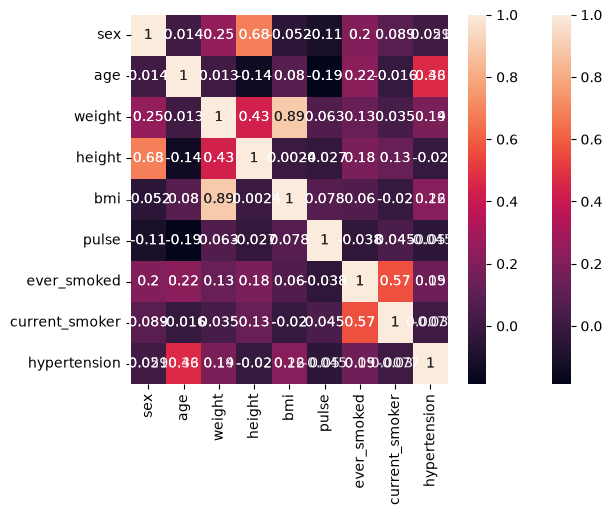

In [47]:
sns.heatmap(pd.concat([X, y_diabetic], axis=1).corr(), annot=True)
sns.heatmap(pd.concat([X, y_hta], axis=1).corr(), annot=True)


## Logistic Regression baseline

In [49]:

'''
Scaling the dataset
'''
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features = ['age', 'weight', 'height', 'bmi', 'pulse']

X_features_scaled = pd.DataFrame(
    scaler.fit_transform(X[features]),
    columns=features,
    index=X.index
)

X_scaled = pd.concat(
    [
        X_features_scaled,
        X[['ever_smoked', 'current_smoker']]
    ],
    axis=1
)
y_diabetic = df1['diabetes']
y_hypertensive = df1['hypertension']

X_scaled


,age,weight,height,bmi,pulse,ever_smoked,current_smoker
2,0.933809,-0.100674,-0.825757,0.315450,-1.707998,1.0,0.0
3,-1.528837,-0.679131,0.909805,-1.067639,0.847695,0.0,0.0
6,1.395556,0.306876,-1.543921,1.291748,0.166177,1.0,1.0
8,0.420758,-0.863186,0.401106,-1.094759,-0.856100,0.0,0.0
9,-1.528837,-1.003418,0.620545,-1.311714,-0.344962,1.0,1.0
...,...,...,...,...,...,...,...
9245,-0.861870,-1.266353,-0.456701,-1.243915,0.847695,1.0,0.0
9246,-0.759260,-0.214612,1.348683,-0.769326,2.040352,1.0,1.0
9250,-0.297514,0.683750,-0.167440,0.871398,0.506936,1.0,0.0
9251,-0.348819,-0.556428,-0.396854,-0.443893,0.506936,0.0,0.0


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.multiclass import OneVsRestClassifier

model_d = LogisticRegression(random_state=42)
model_hta = LogisticRegression(random_state=42)


X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_scaled, y_diabetic, train_size=0.7, random_state=42, stratify=y_diabetic)
X_train_hta, X_test_hta, y_train_hta, y_test_hta = train_test_split(X_scaled, y_hta, train_size=0.7, random_state=42, stratify=y_diabetic)

model_d.fit(X_train_d, y_train_d)
model_hta.fit(X_train_hta, y_train_hta)


cv_d = cross_validate(model_d, X_train_d, y_train_d, cv=5, scoring=['roc_auc'])
cv_hta = cross_validate(model_hta, X_train_hta, y_train_hta, cv=5, scoring=['roc_auc'])


cv_d['test_roc_auc'].mean(), cv_hta['test_roc_auc'].mean()

(np.float64(0.8060916705895409), np.float64(0.8072298121327266))

In [ ]:
from sklearn.metrics import roc_auc_score
def model_f(y):
    """ params={
        'n_estimators': 400,
        'max_depth': 6,
        'learning_rate': 0.9964688888846461,
        'min_child_weight': 1, 'subsample': 0.5004689439033313,
        'colsample_bytree': 0.7613304427154312,
        'gamma': 0.054181861010946, 'reg_alpha': 0.05914008164898518,
        'reg_lambda': 1.1933199710131277e-06
    } """
    model_xgb = XGBClassifier()

    model_xgb.fit(X, y)

    cv_xgb = cross_validate(model_xgb, X, y, cv=5, scoring=['roc_auc'])

    skf = StratifiedKFold(n_splits=5)
    skf.get_n_splits()

    scores = []

    for i, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train = X_scaled.iloc[train_index]
        y_train = y.iloc[train_index]
        X_test = X_scaled.iloc[test_index]
        y_test = y.iloc[test_index]

        model_xgb = XGBClassifier(eval_metric='logloss')

        model_xgb.fit(X_train, y_train)

        y_pred = model_xgb.predict_proba(X_test)[:, 1]


        scores.append(roc_auc_score(y_test, y_pred))
    return np.mean(scores)

In [ ]:
scores_d = model_f(y_diabetic)
scores_hta = model_f(y_hypertensive)

In [ ]:
scores_d, scores_hta

(np.float64(0.7649019502570575), np.float64(0.7647508139920551))

In [58]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = X
y = y_diabetic

def objective(trial):
    # clasificador
    classifier_name = trial.suggest_categorical('classifier', ['XGBClassifier']) #, 'LogisticRegression', 'RandomForestClassifier'

    if classifier_name == 'XGBClassifier':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'eval_metric': 'logloss',
            'random_state': 42,
            'n_jobs': -1
        }


    # Kfolds
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    X_arr = np.array(X)
    y_arr = np.array(y_diabetic)

    for train_idx, val_idx in skf.split(X_arr, y_arr):
        X_train, X_test = X_arr[train_idx], X_arr[val_idx]
        y_train, y_test = y_arr[train_idx], y_arr[val_idx]

        #if classifier_name == 'XGBClassifier':
        model = XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        #elif classifier_name == 'LogisticRegression':
        #    model = LogisticRegression(**params)
        #    model.fit(X_train, y_train)
        #else:
        #    model = RandomForestClassifier(**params)
        #    model.fit(X_train, y_train)

        preds = model.predict_proba(X_test)
        score = roc_auc_score(y_test, preds[:,1])
        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

print("Mejor ROC_AUC:", study.best_value)
print("Mejores parámetros:", study.best_params)


[I 2026-08-31 17:39:53,794] A new study created in memory with name: no-name-45499953-2594-4162-a1f3-26496ba89daf
[I 2026-08-31 17:39:55,596] Trial 0 finished with value: 0.8062398339013743 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.039836573247176196, 'min_child_weight': 3, 'subsample': 0.8583189161770954, 'colsample_bytree': 0.530493858944208, 'gamma': 0.0009400787571576377, 'reg_alpha': 1.250096583235791, 'reg_lambda': 0.3005370849695669}. Best is trial 0 with value: 0.8062398339013743.
[I 2026-08-31 17:39:58,414] Trial 1 finished with value: 0.8020700964916786 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.05377591978147206, 'min_child_weight': 5, 'subsample': 0.8690795212237381, 'colsample_bytree': 0.9342496618883067, 'gamma': 3.9105461175524236e-07, 'reg_alpha': 1.2076589144393564e-07, 'reg_lambda': 0.16827303279853525}. Best is trial 0 with value: 0.8062398339013

Mejor ROC_AUC: 0.810844213996028
Mejores parámetros: {'classifier': 'XGBClassifier', 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.010677190225220949, 'min_child_weight': 1, 'subsample': 0.6043561958157714, 'colsample_bytree': 0.8295037165592025, 'gamma': 3.669236122930393e-05, 'reg_alpha': 4.3504647294127315e-08, 'reg_lambda': 1.6041030962313092}


In [60]:
from pulseiq.ml_logic.registry import save_model, load_model, save_model_into_bucket

params = {'classifier': 'XGBClassifier', 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.010677190225220949, 'min_child_weight': 1, 'subsample': 0.6043561958157714, 'colsample_bytree': 0.8295037165592025, 'gamma': 3.669236122930393e-05, 'reg_alpha': 4.3504647294127315e-08, 'reg_lambda': 1.6041030962313092}
model_t = train_model(XGBClassifier, X, y_diabetic, params)
save_model_into_bucket(model_t, DIABETES_SYNTAXIS)


/home/candelaneumann/.pyenv/versions/pulse_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "classifier" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
model_d = load_model('diabetic')

prediction = model_d.predict(X_test_d)

prediction.mean()

np.float64(0.020075282308657464)

## Hypertensive



In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = X
y = y_hypertensive

def objective(trial):
    # clasificador
    classifier_name = trial.suggest_categorical('classifier', ['XGBClassifier']) #, 'LogisticRegression', 'RandomForestClassifier'

    if classifier_name == 'XGBClassifier':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'eval_metric': 'logloss',
            'random_state': 42,
            'n_jobs': -1
        }


    # Kfolds
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    X_arr = np.array(X)
    y_arr = np.array(y_hypertensive)

    for train_idx, val_idx in skf.split(X_arr, y_arr):
        X_train, X_test = X_arr[train_idx], X_arr[val_idx]
        y_train, y_test = y_arr[train_idx], y_arr[val_idx]

        #if classifier_name == 'XGBClassifier':
        model = XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        #elif classifier_name == 'LogisticRegression':
        #    model = LogisticRegression(**params)
        #    model.fit(X_train, y_train)
        #else:
        #    model = RandomForestClassifier(**params)
        #    model.fit(X_train, y_train)

        preds = model.predict_proba(X_test)
        score = roc_auc_score(y_test, preds[:,1])
        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

print("Mejor ROC_AUC:", study.best_value)
print("Mejores parámetros:", study.best_params)


[I 2026-08-31 17:54:27,803] A new study created in memory with name: no-name-8d30a6bd-a6e3-401a-98ca-1664cf22139d
[I 2026-08-31 17:54:41,197] Trial 0 finished with value: 0.7676435911445196 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 900, 'max_depth': 3, 'learning_rate': 0.18641292478679422, 'min_child_weight': 3, 'subsample': 0.7018210440947534, 'colsample_bytree': 0.6731036623354008, 'gamma': 0.00015073615168534793, 'reg_alpha': 0.008693449293802802, 'reg_lambda': 2.146351425100797}. Best is trial 0 with value: 0.7676435911445196.
[I 2026-08-31 17:54:51,181] Trial 1 finished with value: 0.7885525989028331 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 600, 'max_depth': 7, 'learning_rate': 0.17015875192845806, 'min_child_weight': 1, 'subsample': 0.9873352993078134, 'colsample_bytree': 0.6203676457101885, 'gamma': 0.06919909485246227, 'reg_alpha': 2.4271933182002123, 'reg_lambda': 0.4966577451920028}. Best is trial 1 with value: 0.7885525989028331.


In [ ]:
params = {'n_classifier': 'XGBClassifier', 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03223608863515274, 'min_child_weight': 9, 'subsample': 0.7343774784187223, 'colsample_bytree': 0.6797647434673, 'gamma': 0.03060045238753461, 'reg_alpha': 0.07489952644210322, 'reg_lambda': 8.502205392435497}
model_t = train_model(XGBClassifier, X, y_hypertensive, params)
save_model_into_bucket(model_t, DIABETES_SYNTAXIS)


/home/candelaneumann/.pyenv/versions/pulse_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:12:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "n_classifier" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Artefactos guardados: [hypertensive_NHANES_final_2       1.0
3       0.0
6       1.0
8       0.0
9       0.0
       ... 
9245    0.0
9246    0.0
9250    0.0
9251    0.0
9253    1.0
Name: hypertension, Length: 5311, dtype: float64] en models/


In [ ]:
model_h = load_model('hypertensive')

prediction = model_h.predict(X_test_hta)

prediction.mean()

np.float64(0.2590966122961104)

,id,sex,age,weight,height,bmi,pulse,ever_smoked,current_smoker
2,93705.0,0,66.0,79.5,158.3,31.7,52.0,1.0,0.0
3,93706.0,1,18.0,66.3,175.7,21.5,82.0,0.0,0.0
6,93709.0,0,75.0,88.8,151.1,38.9,74.0,1.0,1.0
8,93711.0,1,56.0,62.1,170.6,21.3,62.0,0.0,0.0
9,93712.0,1,18.0,58.9,172.8,19.7,68.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...
9245,102948.0,0,31.0,52.9,162.0,20.2,82.0,1.0,0.0
9246,102949.0,1,33.0,76.9,180.1,23.7,96.0,1.0,1.0
9250,102953.0,1,42.0,97.4,164.9,35.8,78.0,1.0,0.0
9251,102954.0,0,41.0,69.1,162.6,26.1,78.0,0.0,0.0


In [ ]:
from pulseiq.ml_logic.oof_function import train_stacking_ensemble
from pulseiq.ml_logic.registry import save_model
import catboost as cb
import numpy as np
import optuna

In [ ]:

import numpy as np
import pandas as pd
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split

from pulseiq.ml_logic.data import download_clean_data, preprocess
from pulseiq.ml_logic.oof_function import train_stacking_ensemble
from pulseiq.ml_logic.registry import save_model
from pulseiq.params import DATABASE_PATH


def predict_stacking_proba(base_models: dict, meta_model, X):
    """
    Genera las probabilidades predichas pasando primero por los 3 modelos base
    y luego por el Meta-XGBoost.
    """
    meta_features = [
        model.predict_proba(X)[:, 1] for _, model in base_models.items()
    ]
    X_meta = np.column_stack(meta_features)
    return meta_model.predict_proba(X_meta)[:, 1]


def evaluate_and_test(target_name: str, base_models: dict, meta_model, X_test, y_test):
    """
    Evalúa el ensemble final en el conjunto de prueba (Hold-out Test).
    """
    test_probs = predict_stacking_proba(base_models, meta_model, X_test)
    auc = roc_auc_score(y_test, test_probs)
    brier = brier_score_loss(y_test, test_probs)

    print(f"\n==================== RESULTADOS: {target_name.upper()} ====================")
    print(f"ROC-AUC Test: {auc:.4f} | Brier Score: {brier:.4f}")

    # Muestra de 5 predicciones
    y_test_arr = y_test.values if hasattr(y_test, "values") else y_test
    print("\nPrimeras 5 predicciones en pacientes de prueba:")
    for i in range(min(5, len(test_probs))):
        print(
            f"  Paciente {i+1} -> Probabilidad: {test_probs[i]:.4f} "
            f"({test_probs[i]*100:.1f}%) | Real: {int(y_test_arr[i])}"
        )

    return {"roc_auc": round(auc, 4), "brier_score": round(brier, 4)}


In [ ]:



# =========================================================================
# [1/3] TARGET: DIABETES
# =========================================================================
print("\n" + "=" * 35 + " [1/2] TARGET: DIABETES " + "=" * 35)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X, y_diabetic, test_size=0.2, random_state=42, stratify=y_diabetic
)

# Entrena los 3 modelos base con Optuna, genera OOF y entrena el Meta-XGBoost
base_models_d, meta_d = train_stacking_ensemble(
    X=X_train_d,
    y=y_train_d,
    target_name="diabetes",
    n_trials_base=20,
    n_trials_meta=20,
)

metrics_d = evaluate_and_test("Diabetes", base_models_d, meta_d, X_test_d, y_test_d)
save_model(
    model={"base_models": base_models_d, "meta_model": meta_d},
    params=metrics_d,
    model_name="ensemble",
    target="diabetes",
)

# =========================================================================
# [2/3] TARGET: HYPERTENSION
# =========================================================================
print("\n" + "=" * 35 + " [2/2] TARGET: HYPERTENSION " + "=" * 35)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X, y_hypertensive, test_size=0.2, random_state=42, stratify=y_hypertensive
)

base_models_h, meta_h = train_stacking_ensemble(
    X=X_train_h,
    y=y_train_h,
    target_name="hypertension",
    n_trials_base=20,
    n_trials_meta=20,
)

metrics_h = evaluate_and_test("Hypertension", base_models_h, meta_h, X_test_h, y_test_h)
save_model(
    model={"base_models": base_models_h, "meta_model": meta_h},
    params=metrics_h,
    model_name="ensemble",
    target="hypertension",
)

# =========================================================================
# RESUMEN FINAL EN CONSOLA
# =========================================================================
print("\n" + "=" * 50)
print("       🏆 RESUMEN ROC-AUC FINAL (HOLD-OUT TEST)")
print("=" * 50)
print(f" -> Diabetes:       ROC-AUC = {metrics_d['roc_auc']:.4f}")
print(f" -> Hypertension:   ROC-AUC = {metrics_h['roc_auc']:.4f}")



=================================== [1/2] TARGET: DIABETES ===================================

[Optuna Base] Optimizando xgboost para target 'diabetes'...
✅ Artefactos guardados: [xgboost_diabetes] en models/

[Optuna Base] Optimizando randomforest para target 'diabetes'...
✅ Artefactos guardados: [randomforest_diabetes] en models/

[Optuna Base] Optimizando catboost para target 'diabetes'...
✅ Artefactos guardados: [catboost_diabetes] en models/
Generando OOF para: xgboost...
Generando OOF para: randomforest...
Generando OOF para: catboost...

[Optuna Meta] Optimizando Meta-XGBoost para 'diabetes' (20 trials)...
   [OK] Meta-XGBoost final entrenado | Mejor CV ROC-AUC: 0.8049


/home/candelaneumann/.pyenv/versions/pulse_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



==================== RESULTADOS: DIABETES ====================
ROC-AUC Test: 0.7934 | Brier Score: 0.1084

Primeras 5 predicciones en pacientes de prueba:
  Paciente 1 -> Probabilidad: 0.4067 (40.7%) | Real: 1
  Paciente 2 -> Probabilidad: 0.0176 (1.8%) | Real: 0
  Paciente 3 -> Probabilidad: 0.1491 (14.9%) | Real: 0
  Paciente 4 -> Probabilidad: 0.2874 (28.7%) | Real: 0
  Paciente 5 -> Probabilidad: 0.1723 (17.2%) | Real: 0
✅ Artefactos guardados: [ensemble_diabetes] en models/

=================================== [2/2] TARGET: HYPERTENSION ===================================

[Optuna Base] Optimizando xgboost para target 'hypertension'...
✅ Artefactos guardados: [xgboost_hypertension] en models/

[Optuna Base] Optimizando randomforest para target 'hypertension'...
✅ Artefactos guardados: [randomforest_hypertension] en models/

[Optuna Base] Optimizando catboost para target 'hypertension'...
✅ Artefactos guardados: [catboost_hypertension] en models/
Generando OOF para: xgboost...
Gen

/home/candelaneumann/.pyenv/versions/pulse_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



==================== RESULTADOS: HYPERTENSION ====================
ROC-AUC Test: 0.8216 | Brier Score: 0.1606

Primeras 5 predicciones en pacientes de prueba:
  Paciente 1 -> Probabilidad: 0.1529 (15.3%) | Real: 0
  Paciente 2 -> Probabilidad: 0.6060 (60.6%) | Real: 1
  Paciente 3 -> Probabilidad: 0.4467 (44.7%) | Real: 1
  Paciente 4 -> Probabilidad: 0.6292 (62.9%) | Real: 1
  Paciente 5 -> Probabilidad: 0.4688 (46.9%) | Real: 0
✅ Artefactos guardados: [ensemble_hypertension] en models/

       🏆 RESUMEN ROC-AUC FINAL (HOLD-OUT TEST)
 -> Diabetes:       ROC-AUC = 0.7934
 -> Hypertension:   ROC-AUC = 0.8216
